# 02 — EPMA, olivine (session 01–02/03/2017)

Same skeleton as 01, with two additions the glass did not need: a **drift correction that is actually applied** (unlike the glass, the drift here is resolved well above precision), and **cation stoichiometry**, which gives an independent check on the data that a total alone cannot.

Input: `outputs/interim/ol_*.csv`. The samples are the olivine hosts of melt inclusions; 128 analyses, 15 of them SC-Olivine.

In [1]:
# --- config ---
from pathlib import Path
import sys, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

ROOT = Path.cwd()
INTERIM = ROOT / "outputs" / "interim"
STEP = "olivine"
OUT = ROOT / "outputs" / STEP; FIG = ROOT / "figures" / STEP
for d in (OUT, FIG): d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))
from geohelpers import q_test, summarize, load_ref_olivine, forsterite, cation_ratio

OX = ["SiO2", "MgO", "FeO", "MnO", "CaO", "Cr2O3", "NiO", "Al2O3"]
SAVE = True
pd.set_option("display.width", 200, "display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 9})

ol = (pd.read_csv(INTERIM / "ol_oxide.csv")
        .merge(pd.read_csv(INTERIM / "ol_meta.csv", parse_dates=["datetime"])[["No.", "datetime", "curr_A"]], on="No."))
rat = pd.read_csv(INTERIM / "ol_ratios.csv")          # JEOL's own Fo/Fa, used only to check ours
intens = pd.read_csv(INTERIM / "ol_intensity.csv")
ref = load_ref_olivine(ROOT / "data" / "Standards.xlsx")
ol["minutes"] = (ol.datetime - ol.datetime.min()).dt.total_seconds() / 60
print("SC-Olivine reference:", ref.round(3).to_dict())
print(ol.shape, "| standards:", ol.is_std.sum(), "| sample spots:", (~ol.is_std).sum())

SC-Olivine reference: {'SiO2': 40.81, 'Al2O3': 0.033, 'FeO': 9.55, 'MnO': 0.14, 'MgO': 49.42, 'CaO': 0.092, 'Cr2O3': 0.014, 'NiO': 0.37}
(128, 18) | standards: 15 | sample spots: 113


## 1. Run structure

Five brackets of three SC-Olivine analyses each, separating four sample batches over a 7-hour overnight session. Denser bracketing than the glass session, which is what makes a time-resolved drift correction possible here.

In [2]:
EDGES = [(1, 3), (25, 27), (59, 61), (89, 91), (126, 128)]
ol["bracket"] = np.nan
for i, (a, b) in enumerate(EDGES, 1):
    ol.loc[ol["No."].between(a, b), "bracket"] = i

print(ol[ol.is_std].groupby("bracket").agg(first=("No.", "min"), last=("No.", "max"),
                                            time=("datetime", "min")).to_string())
spots = ol[~ol.is_std].groupby("sample").size()
print("\nsession %.1f h | %d grains | spots per grain: %s"
      % (ol.minutes.max() / 60, spots.size, dict(spots.value_counts().sort_index())))
print("beam: %.0f kV, %.0f nA, focused (probe dia 0)"
      % (15, ol.curr_A.mean() * 1e9))

         first  last                time
bracket                                 
1.0          1     3 2017-03-02 02:12:00
2.0         25    27 2017-03-02 03:33:00
3.0         59    61 2017-03-02 05:29:00
4.0         89    91 2017-03-02 07:11:00
5.0        126   128 2017-03-02 09:16:00

session 7.2 h | 37 grains | spots per grain: {3: np.int64(35), 4: np.int64(2)}
beam: 15 kV, 99 nA, focused (probe dia 0)


## 2. Precision

Quoted two ways on purpose. **Within-bracket** 2SD is the repeatability of three analyses minutes apart; **session** 2SD is the reproducibility over seven hours. Where the two differ, the difference *is* the drift.

In [3]:
std = ol[ol.is_std]
prec = pd.DataFrame({"mean": std[OX].mean(),
                     "2SD_within": (2 * std.groupby("bracket")[OX].std()).mean(),
                     "2SD_session": 2 * std[OX].std()})
prec["2RSD%_within"] = 100 * prec["2SD_within"] / prec["mean"]
prec["2RSD%_session"] = 100 * prec["2SD_session"] / prec["mean"]
prec["drift_inflation"] = prec["2SD_session"] / prec["2SD_within"]
print(prec.round(4).to_string())

          mean  2SD_within  2SD_session  2RSD%_within  2RSD%_session  drift_inflation
SiO2   40.0907      0.1733       1.2565        0.4322         3.1342           7.2524
MgO    49.7353      0.1790       0.2863        0.3599         0.5757           1.5999
FeO     9.5067      0.1329       0.1409        1.3979         1.4826           1.0606
MnO     0.1433      0.0091       0.0085        6.3572         5.9086           0.9294
CaO     0.1018      0.0042       0.0040        4.1000         3.9663           0.9674
Cr2O3   0.0153      0.0116       0.0129       75.8956        84.5435           1.1139
NiO     0.3535      0.0330       0.0448        9.3315        12.6630           1.3570
Al2O3   0.0340      0.0079       0.0078       23.4097        22.9529           0.9805


Seven of eight oxides reproduce over seven hours as well as they do over three minutes — the session 2SD equals the within-bracket 2SD, so nothing is moving.

**SiO₂ is the exception: 0.17 wt% within a bracket, 1.26 wt% across the session — an inflation factor of 7.** That is not scatter, it is a trend, and it has to be dealt with before anything else is computed.

## 3. Drift in SiO₂

Bracket means with time, against the SC-Olivine reference value of 40.81 wt% (which is also the value the machine was calibrated on, from `_std-cnd`).

          minutes     SiO2      MgO     FeO     MnO     CaO   Cr2O3     NiO   Al2O3
bracket                                                                            
1.0        3.0000  39.7100  49.6767  9.5567  0.1444  0.1014  0.0217  0.3650  0.0330
2.0       84.6667  39.5733  49.7300  9.4933  0.1432  0.1023  0.0135  0.3544  0.0334
3.0      200.0000  39.7200  49.9333  9.5500  0.1433  0.1026  0.0100  0.3627  0.0345
4.0      302.3333  40.2467  49.7367  9.4633  0.1437  0.1009  0.0169  0.3264  0.0329
5.0      427.6667  41.2033  49.6000  9.4700  0.1420  0.1017  0.0143  0.3592  0.0359

SiO2: bracket means span 1.63 wt% against a within-bracket 2SD of 0.17
MgO:  bracket means span 0.33 wt% against a within-bracket 2SD of 0.18


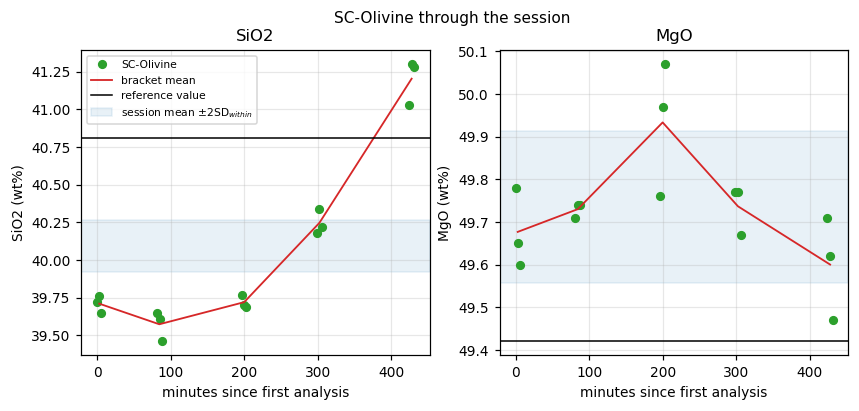

In [4]:
bm = std.groupby("bracket")[["minutes"] + OX].mean()
print(bm.round(4).to_string())
print("\nSiO2: bracket means span %.2f wt%% against a within-bracket 2SD of %.2f"
      % (bm.SiO2.max() - bm.SiO2.min(), prec.loc["SiO2", "2SD_within"]))
print("MgO:  bracket means span %.2f wt%% against a within-bracket 2SD of %.2f"
      % (bm.MgO.max() - bm.MgO.min(), prec.loc["MgO", "2SD_within"]))

fig, axs = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, ox in zip(axs, ["SiO2", "MgO"]):
    ax.plot(std.minutes, std[ox], "o", ms=5, color="tab:green", label="SC-Olivine")
    ax.plot(bm.minutes, bm[ox], "-", color="tab:red", lw=1.2, label="bracket mean")
    ax.axhline(ref[ox], color="k", lw=1, label="reference value")
    w = prec.loc[ox, "2SD_within"]
    mu = std[ox].mean()
    ax.axhspan(mu - w, mu + w, color="tab:blue", alpha=.10, label="session mean ±2SD$_{within}$")
    ax.set(xlabel="minutes since first analysis", ylabel=f"{ox} (wt%)", title=ox)
    ax.grid(alpha=.3)
axs[0].legend(fontsize=7)
fig.suptitle("SC-Olivine through the session", fontsize=10)
if SAVE: fig.savefig(FIG / "fig01_drift_olivine.png")
plt.show()

SiO₂ holds steady near 39.6–39.7 wt% for the first three hours and then climbs steeply to 41.20 wt% — a 1.5 wt% (4 %) swing against a within-bracket 2SD of 0.17, crossing the true value about three-quarters of the way through. Si is under-reported by ~2.7 % early and over-reported by ~1 % at the end. **The drift is real but not linear**: it is concentrated in the last third of the session, which is why a single session-wide factor would be wrong and the bracket structure matters.

MgO over the same seven hours moves by 0.33 wt%, only twice its within-bracket 2SD and with no trend — it sits consistently ~0.3 wt% above its reference value, which is an accuracy offset (section 4), not drift. So the problem is the Si channel alone: spectrometer or crystal, not the beam current (stable to 0.5 %) and not the overall calibration, which would move every oxide together.

**Decision: correct SiO₂, and only SiO₂.** The factor k = 40.81 / (SC-Ol measured SiO₂) is computed per bracket and **interpolated linearly in time** onto each analysis, so a sample is corrected by the drift happening around it rather than by a session average. No other oxide shows a trend to correct.

Unlike the glass session, this is worth doing: the trend is 7× the repeatability and it is anchored by five brackets, so the correction is far better determined than the noise it removes.

In [5]:
k = ref["SiO2"] / bm["SiO2"]
ol["k_Si"] = np.interp(ol.minutes, bm.minutes, k)
ol["SiO2_corr"] = ol.SiO2 * ol.k_Si
ol["Total_corr"] = ol.Total - ol.SiO2 + ol.SiO2_corr
print("k per bracket:", k.round(4).to_dict())

chk = pd.DataFrame({"raw": [std.SiO2.mean(), 200 * std.SiO2.std() / std.SiO2.mean()],
                    "corrected": [ol.loc[ol.is_std, "SiO2_corr"].mean(),
                                  200 * ol.loc[ol.is_std, "SiO2_corr"].std() / ol.loc[ol.is_std, "SiO2_corr"].mean()]},
                   index=["SC-Ol mean SiO2 (wt%)", "SC-Ol 2RSD (%)"])
print("\nvalidation 1 — does the standard reproduce better after correction?")
print(chk.round(3).to_string())

k per bracket: {1.0: 1.0277, 2.0: 1.0313, 3.0: 1.0274, 4.0: 1.014, 5.0: 0.9905}

validation 1 — does the standard reproduce better after correction?
                          raw  corrected
SC-Ol mean SiO2 (wt%)  40.091     40.810
SC-Ol 2RSD (%)          3.134      0.378


### Independent validation: cation stoichiometry

The standard reproducing itself after a correction derived from the standard is circular. Olivine gives a check that is not: in (Mg,Fe,Mn,Ca,Ni)₂SiO₄ the ratio of divalent cations to Si must be **2.000**, whatever the Fo content, and nothing in the correction was tuned to make that true. (The SC-Olivine reference values themselves give 2.014 rather than 2.000, because they are rounded to two decimals — that is the target to beat, not 2.000.)

In [6]:
ol["MT_raw"] = cation_ratio(ol, si="SiO2")
ol["MT_corr"] = cation_ratio(ol, si="SiO2_corr")
ref_MT = cation_ratio(pd.DataFrame([ref]), si="SiO2").iloc[0]

print("reference SC-Olivine stoichiometry: %.4f\n" % ref_MT)
print(ol.groupby(np.where(ol.is_std, "SC-Olivine", "samples"))[["MT_raw", "MT_corr"]]
        .agg(["mean", "std"]).round(4).to_string())

reference SC-Olivine stoichiometry: 2.0136

            MT_raw         MT_corr        
              mean     std    mean     std
SC-Olivine  2.0611  0.0354  2.0242  0.0080
samples     2.0508  0.0351  2.0125  0.0373


The correction is confirmed from outside itself. Cation ratios move from 2.061 to 2.024 (standards) and 2.051 to 2.013 (samples) against a reference target of 2.014, and the scatter on the standards collapses from 0.035 to 0.008 — a fourfold tightening on a quantity the correction never saw.

Two things to carry into the report:

* **The residual scatter on the samples is ±0.037 (±1.9 %), much larger than the ±0.008 of the standards.** The bracket-to-bracket drift is not perfectly linear in time, so interpolating between brackets leaves a few percent of Si error on analyses far from a bracket. That residual, not the counting statistics, is the real uncertainty on sample SiO₂: **quote SiO₂ to ±2 % relative, not to the ±0.4 % the corrected standards suggest.**
* Stoichiometry is a ratio, so it is blind to a uniform scale error — which is exactly what section 4 turns out to need.

## 4. Accuracy

SC-Olivine measured against its reference values. As in the glass session, read it knowing what calibrates what: **SC-Ol itself calibrates SiO₂, MgO and FeO**, so those three are near-circular. CaO (Wollastonite), MnO (Rhodonite), NiO (pure NiO), Cr₂O₃ (pure Cr₂O₃) and Al₂O₃ (Corundum) are calibrated on completely different matrices, and those are the meaningful accuracy tests.

In [7]:
acc = pd.DataFrame({"reference": ref[OX],
                    "measured": std[OX].mean(),
                    "measured_corr": ol.loc[ol.is_std, ["SiO2_corr"] + OX[1:]].mean().rename({"SiO2_corr": "SiO2"}),
                    "2SD": prec["2SD_session"]})
acc["dev_pct"] = 100 * (acc.measured - acc.reference) / acc.reference
acc["dev_pct_corr"] = 100 * (acc.measured_corr - acc.reference) / acc.reference
acc["calibrated_on"] = ["SC-Ol", "SC-Ol", "SC-Ol", "Rhodonite", "Wollastonite", "Cr2O3", "NiO", "Corundum"]
acc["problem"] = (acc.measured_corr - acc.reference).abs() > acc["2SD"]
print(acc.round(4).to_string())

       reference  measured  measured_corr     2SD  dev_pct  dev_pct_corr calibrated_on  problem
SiO2      40.810   40.0907        40.8102  1.2565  -1.7626        0.0004         SC-Ol    False
MgO       49.420   49.7353        49.7353  0.2863   0.6381        0.6381         SC-Ol     True
FeO        9.550    9.5067         9.5067  0.1409  -0.4538       -0.4538         SC-Ol    False
MnO        0.140    0.1433         0.1433  0.0085   2.3714        2.3714     Rhodonite    False
CaO        0.092    0.1018         0.1018  0.0040  10.6232       10.6232  Wollastonite     True
Cr2O3      0.014    0.0153         0.0153  0.0129   9.1429        9.1429         Cr2O3    False
NiO        0.370    0.3535         0.3535  0.0448  -4.4486       -4.4486           NiO    False
Al2O3      0.033    0.0340         0.0340  0.0078   2.9091        2.9091      Corundum    False


* **CaO is +10.6 %** (0.102 vs 0.092 wt%), far beyond its 2SD of 0.004 — the clearest accuracy problem in this session. CaO is calibrated on Wollastonite (47.7 wt% CaO) and applied to olivine at 0.1–0.4 wt%: a 500-fold extrapolation across a different matrix. The absolute error is only 0.01 wt%, which matters little for a total but matters a great deal if CaO-in-olivine is used as a thermometer or as a proxy for melt composition. **Report CaO with the +10 % bias stated.**
* NiO reads −4.5 % and MnO +2.4 %, both within 2SD, so they are usable as-is.
* Cr₂O₃ reads +9 % with 85 % 2RSD — the deviation is meaningless because the precision is meaningless (section 7).
* MgO is +0.6 % and trips the criterion only because its 2SD is small. **This answers the question carried over from 01: MgO is fine here.** The +6 % MgO bias in the glass session is specific to that session's Mg calibration, not a standing problem with the instrument's Mg channel.
* SiO₂ after correction sits on its reference by construction (−1.8 % before), which is why it cannot be used as evidence of accuracy — hence the stoichiometry check above.

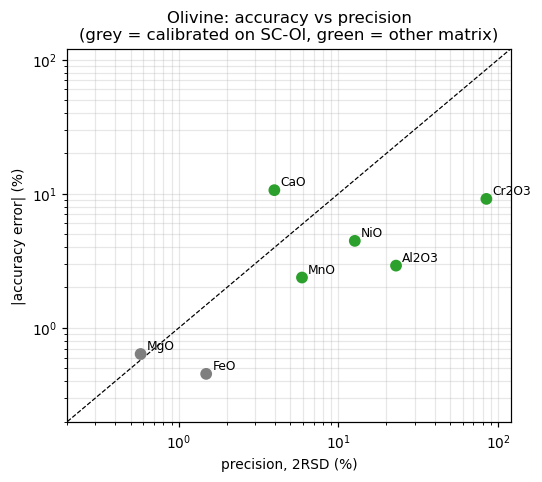

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
d = acc.drop(index=["SiO2"])
colour = np.where(d.calibrated_on == "SC-Ol", "tab:grey", "tab:green")
ax.scatter(d["2RSD%_session"] if "2RSD%_session" in d else 100 * d["2SD"] / d.measured,
           d.dev_pct_corr.abs(), c=colour, s=45, zorder=3)
for ox, r in d.iterrows():
    ax.annotate(ox, (100 * r["2SD"] / r.measured, abs(r.dev_pct_corr)), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
lim = [0.2, 120]
ax.plot(lim, lim, "k--", lw=.8)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel="precision, 2RSD (%)", ylabel="|accuracy error| (%)",
       title="Olivine: accuracy vs precision\n(grey = calibrated on SC-Ol, green = other matrix)")
ax.grid(alpha=.3, which="both")
if SAVE: fig.savefig(FIG / "fig02_accuracy_vs_precision_olivine.png")
plt.show()

## 5. Totals

Olivine has no volatiles and negligible Fe³⁺, so unlike the glass there is no legitimate geological reason for a total to sit away from ~100 wt%. That makes the total a stricter test here — and it fails.

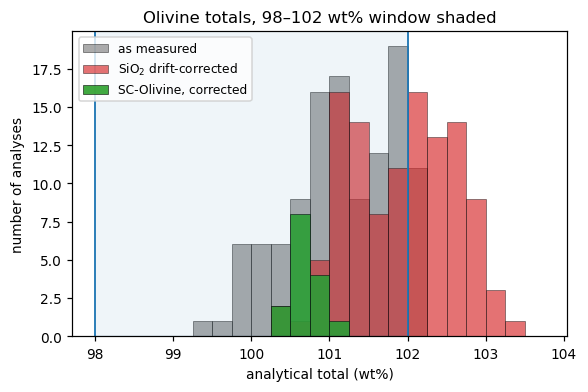

samples   as measured: mean 101.17, 11 of 113 outside 98-102
samples   corrected:   mean 101.92, 56 outside
SC-Olivine corrected:  mean 100.70 (reference values sum to 100.43)


In [9]:
smp = ol[~ol.is_std].copy()
fig, ax = plt.subplots(figsize=(5.8, 3.6))
bins = np.arange(98, 104, 0.25)
ax.hist(smp.Total, bins=bins, alpha=.65, label="as measured", color="tab:grey", edgecolor="k", lw=.4)
ax.hist(smp.Total_corr, bins=bins, alpha=.65, label="SiO$_2$ drift-corrected", color="tab:red", edgecolor="k", lw=.4)
ax.hist(ol.loc[ol.is_std, "Total_corr"], bins=bins, alpha=.9, label="SC-Olivine, corrected", color="tab:green", edgecolor="k", lw=.4)
for x in (98, 102): ax.axvline(x, color="tab:blue", lw=1.2)
ax.axvspan(98, 102, color="tab:blue", alpha=.07)
ax.set(xlabel="analytical total (wt%)", ylabel="number of analyses", title="Olivine totals, 98–102 wt% window shaded")
ax.legend(fontsize=8)
if SAVE: fig.savefig(FIG / "fig03_totals_olivine.png")
plt.show()

print("samples   as measured: mean %.2f, %d of %d outside 98-102"
      % (smp.Total.mean(), (~smp.Total.between(98, 102)).sum(), len(smp)))
print("samples   corrected:   mean %.2f, %d outside" % (smp.Total_corr.mean(), (~smp.Total_corr.between(98, 102)).sum()))
print("SC-Olivine corrected:  mean %.2f (reference values sum to %.2f)"
      % (ol.loc[ol.is_std, "Total_corr"].mean(), ref[OX].sum()))

The as-measured totals flag 11 sample spots above 102 wt%. All eleven are in the second half of the session, all are within 0.2 wt% of the limit, and three of them are every spot of one grain (`UnkA-C21MI_18`). They are high because Si was being over-reported late in the session, not because the spots are bad — **rejecting them would delete good analyses for an instrumental reason that has already been corrected.**

After the drift correction the picture is cleaner and worse: sample totals sit at a nearly uniform **101.9 wt%**, while corrected SC-Olivine sits at 100.72 against a reference sum of 100.43. So there is a **~1.5 % scale offset on the samples that the standard does not share**, constant through the session.

Cation stoichiometry says what it is not: the samples are stoichiometric (2.013 vs 2.014 reference), so the oxides are in the right *proportions* and no single oxide is individually wrong. A uniform ~1.5 % scale error on all oxides at once is invisible to a ratio and visible only in the total. Its likely source is the matrix correction being anchored at Fo₉₀, FeO 9.5 wt% (SC-Ol) and applied to samples at Fo₇₉–₈₇, FeO 12–20 wt% — an extrapolation the standard is structurally unable to reveal, because the standard has nothing to extrapolate.

**Decisions:**

1. **No spot is rejected on its total alone.** The 98–102 window is a test for bad *spots*; here it is responding to a session-wide offset that affects every analysis equally. Applying it would remove 11 good analyses and leave the offset untouched.
2. **The offset is reported, not normalised away.** Renormalising every analysis to 100 % would hide a real systematic and change nothing about Fo, Mg# or any element ratio (all of which are scale-invariant). Totals are quoted as measured with the +1.5 % stated.
3. Because Fo, Mg#, Fe/Mn and Ca/Al are all ratios, **none of the conclusions in the geochemistry section depend on this offset.**

## 6. Contamination screen

The risk in these samples is the opposite of the glass session's: the spots are olivine hosts of melt inclusions, so the beam can stray onto the inclusion glass or a cracked rim. That shows as Al₂O₃, CaO or K₂O above what olivine can hold — olivine takes essentially no Al (<0.1 wt% Al₂O₃) and little Ca (<0.4 wt% CaO in magmatic olivine).

       samples_max  samples_median  SC-Ol_mean  olivine_limit
Al2O3       0.0488          0.0296      0.0340           0.10
CaO         0.4093          0.3486      0.1018           0.45
Cr2O3       0.0684          0.0127      0.0153            NaN

spots failing the contamination screen: 0


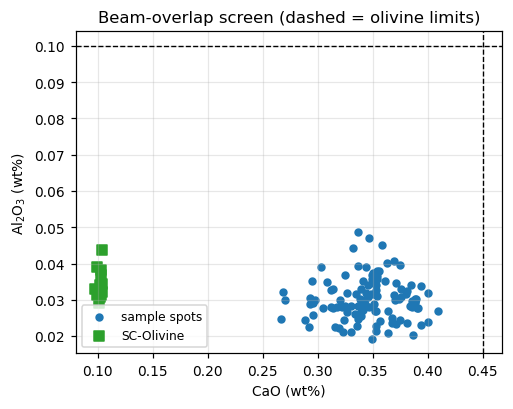

In [10]:
scr = pd.DataFrame({"samples_max": smp[["Al2O3", "CaO", "Cr2O3"]].max(),
                    "samples_median": smp[["Al2O3", "CaO", "Cr2O3"]].median(),
                    "SC-Ol_mean": std[["Al2O3", "CaO", "Cr2O3"]].mean(),
                    "olivine_limit": [0.10, 0.45, np.nan]})
print(scr.round(4).to_string())
smp["fail_contam"] = (smp.Al2O3 > 0.10) | (smp.CaO > 0.45)
print("\nspots failing the contamination screen:", int(smp.fail_contam.sum()))

fig, ax = plt.subplots(figsize=(5.0, 3.8))
ax.scatter(smp.CaO, smp.Al2O3, s=20, c="tab:blue", label="sample spots")
ax.scatter(std.CaO, std.Al2O3, s=35, c="tab:green", marker="s", label="SC-Olivine")
ax.axvline(0.45, color="k", ls="--", lw=.9); ax.axhline(0.10, color="k", ls="--", lw=.9)
ax.set(xlabel="CaO (wt%)", ylabel="Al$_2$O$_3$ (wt%)", title="Beam-overlap screen (dashed = olivine limits)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
if SAVE: fig.savefig(FIG / "fig04_contamination_screen.png")
plt.show()

**No contaminated spots.** Al₂O₃ reaches only 0.049 wt% (half the olivine limit, and within a factor of 1.5 of the SC-Ol standard itself at 0.034) and CaO spans 0.27–0.41 wt%, squarely in the magmatic-olivine range. A spot that clipped the inclusion glass would show Al₂O₃ in whole percent, not hundredths. The focused beam and careful spot placement did their job — worth saying explicitly in the report, since "we checked and found nothing" is a result.

## 7. Q-test, and why it is nearly useless at n = 3

In [11]:
qrows = []
for s, g in smp.groupby("sample"):
    for ox in OX:
        idx, qe, qc = q_test(g.set_index("No.")[ox])
        if idx is not None:
            qrows.append(dict(sample=s, oxide=ox, No=idx, Q_exp=round(qe, 2), Q_crit=qc, n=len(g)))
qt = pd.DataFrame(qrows)
print("flags: %d, on %d of %d grains" % (len(qt), qt['sample'].nunique(), smp['sample'].nunique()))
print(qt.oxide.value_counts().to_string())
print("\nQ_exp distribution of the flags:", qt.Q_exp.describe()[["min", "50%", "max"]].round(2).to_dict())

flags: 39, on 25 of 37 grains
oxide
SiO2     9
Cr2O3    7
NiO      7
CaO      5
Al2O3    4
MgO      3
MnO      2
FeO      2

Q_exp distribution of the flags: {'min': 0.94, '50%': 0.98, 'max': 1.0}


With three spots per grain, Q_exp = gap/range is ≥ 0.94 whenever two of the three points happen to be close together — which is the normal outcome for a slightly zoned crystal. The test throws 39 flags across 25 of 37 grains, most of them on Cr₂O₃ and NiO, and it cannot distinguish a genuine outlier from ordinary zoning.

**Decision: the Q-test is reported but not used to remove anything in this notebook.** At n = 3 it has no discriminating power, and removing a point would leave n = 2 — below the three-point minimum for an average anyway. The glass session, with n = 9, is where the Q-test did real work (it isolated the clinopyroxene). This contrast is itself worth a sentence in the methodology: **the statistical tools available depend on how many spots per sample were measured**, which is a decision made at the microprobe, not afterwards.

## 8. Fo and Mg#, recomputed

Recomputed from the oxides rather than trusting the `_ratios` file. For olivine, Mg# = 100·Mg/(Mg+Fe²⁺) and Fo are the same number, since Mg and Fe²⁺ are the only significant divalent cations on the M site and all Fe is Fe²⁺.

In [12]:
ol["Fo"] = forsterite(ol)
d = ol.Fo - rat["Fo+M"]
print("our Fo vs the JEOL _ratios file: max |difference| = %.4f mol%%, mean = %+.4f" % (d.abs().max(), d.mean()))
print("SC-Olivine: Fo %.3f ± %.3f (2SD %.3f), reference %.2f"
      % (ol.loc[ol.is_std, "Fo"].mean(), ol.loc[ol.is_std, "Fo"].std(),
         2 * ol.loc[ol.is_std, "Fo"].std(), 90.22))
smp["Fo"] = ol.loc[smp.index, "Fo"]
print("samples: Fo %.1f – %.1f" % (smp.Fo.min(), smp.Fo.max()))

our Fo vs the JEOL _ratios file: max |difference| = 0.0087 mol%, mean = +0.0012
SC-Olivine: Fo 90.315 ± 0.060 (2SD 0.119), reference 90.22
samples: Fo 78.7 – 87.2


The recomputed Fo agrees with the JEOL file to better than 0.01 mol% — the residual is only the atomic weights used. The `_ratios` file can be trusted, but the check had to be done rather than assumed, and the recomputation is what lets Fo be propagated with a proper uncertainty.

Fo is also the most robust number in this dataset: it is a ratio of two oxides that both reproduce well (MgO 0.6 % 2RSD, FeO 1.5 %), it is untouched by the SiO₂ drift, and it is immune to the totals offset. SC-Olivine gives Fo 90.32 ± 0.12 (2SD) against a reference of 90.22 — **±0.1 mol% is the realistic uncertainty on any Fo quoted here.**

## 9. Zoning — one population per grain?

Averaging the spots of a zoned crystal produces a number that describes no part of it. With Fo reproducible to 0.12 mol% on the standard, any grain whose spots span much more than that is telling us something real.

In [13]:
fo2sd = 2 * ol.loc[ol.is_std, "Fo"].std()
z = smp.groupby("sample").Fo.agg(["count", "mean", "min", "max"])
z["range"] = z["max"] - z["min"]
z["zoned"] = z["range"] > 0.5                       # >4x the analytical 2SD
print("analytical 2SD on Fo: %.3f mol%%" % fo2sd)
print(z["range"].describe().round(3).to_string())
print("\ngrains with Fo range > 0.5 mol%% (treated as zoned): %d of %d" % (z.zoned.sum(), len(z)))
print(z[z.zoned].round(2).to_string())

analytical 2SD on Fo: 0.119 mol%
count    37.000
mean      0.466
std       0.490
min       0.048
25%       0.159
50%       0.265
75%       0.500
max       1.854

grains with Fo range > 0.5 mol% (treated as zoned): 10 of 37
                   count   mean    min    max  range  zoned
sample                                                     
UnkA-C20-S2-1MI_1      3  85.04  84.56  85.57   1.00   True
UnkA-C20-S2-1MI_4      3  86.81  86.56  87.09   0.52   True
UnkA-C21MI_10          3  83.97  83.44  85.01   1.57   True
UnkA-C21MI_11          3  83.68  83.39  83.89   0.50   True
UnkA-C21MI_12          3  83.57  83.10  84.10   1.00   True
UnkA-C21MI_13          3  82.65  81.97  83.83   1.85   True
UnkA-C21MI_17          3  81.90  81.39  82.50   1.11   True
UnkA-C21MI_2           3  81.30  80.50  81.81   1.31   True
UnkA-C21MI_3           3  84.71  83.85  85.61   1.76   True
UnkA-C21MI_8           3  80.58  80.30  81.00   0.70   True


Most grains are homogeneous at the level the probe can see (median Fo range 0.27 mol%, about twice the analytical 2SD — normal for three spots on one crystal). **Ten grains of 37 span more than 0.5 mol%, half of those by more than 1 mol%, up to 1.85 mol% in `UnkA-C21MI_13`.** These are genuinely zoned: melt-inclusion host olivines commonly have a more evolved rim, and 1–2 mol% Fo is exactly the scale of diffusive re-equilibration around a trapped inclusion.

**Decision: the zoned grains are averaged but flagged, and their 2SD is reported rather than their 2SE.** With three spots there is no way to separate core from rim reliably — we do not have the spot coordinates relative to the grain edge (the `_all` file's stage coordinates are absolute, not radial). Quoting a 2SE for a grain whose spots differ by 1.8 mol% would claim a precision the grain does not have. This matters directly for the melt-inclusion work these olivines support: the host Fo used in any post-entrapment correction should be the one nearest the inclusion, not the grain average.

## 10. Grain averages

In [14]:
smp["SiO2"] = ol.loc[smp.index, "SiO2_corr"]          # report the drift-corrected SiO2
smp["keep"] = ~smp.fail_contam                        # nothing else was rejected; see sections 5-7
avg = summarize(smp[smp.keep], OX + ["Fo"], "sample")

table = avg.pivot(index="sample", columns="oxide", values="mean").reindex(columns=OX + ["Fo"])
table.insert(0, "n", avg.groupby("sample").n.max())
table["Fo_2SD"] = avg.query("oxide == 'Fo'").set_index("sample")["2SD"]
table["Fo_2SE"] = avg.query("oxide == 'Fo'").set_index("sample")["2SE"]
table["zoned"] = z.zoned
print("grains with n < 3:", (table.n < 3).sum())
print(table.round(3).to_string())

grains with n < 3: 0
oxide              n    SiO2     MgO     FeO    MnO    CaO  Cr2O3    NiO  Al2O3      Fo  Fo_2SD  Fo_2SE  zoned
sample                                                                                                        
UnkA-C20-S2-1MI_1  3  40.074  46.013  14.433  0.240  0.348  0.029  0.203  0.032  85.036   1.010   0.583   True
UnkA-C20-S2-1MI_2  3  40.290  44.790  15.303  0.250  0.341  0.011  0.190  0.041  83.915   0.270   0.156  False
UnkA-C20-S2-1MI_3  3  40.530  47.237  12.857  0.211  0.356  0.039  0.208  0.035  86.754   0.186   0.107  False
UnkA-C20-S2-1MI_4  3  40.784  47.400  12.840  0.206  0.357  0.036  0.219  0.032  86.808   0.528   0.305   True
UnkA-C20-S2-1MI_5  3  40.376  46.130  14.327  0.231  0.321  0.037  0.207  0.031  85.162   0.056   0.032  False
UnkA-C20-S2-1MI_6  3  39.991  47.297  12.843  0.211  0.358  0.037  0.219  0.029  86.780   0.359   0.207  False
UnkA-C20-S2-1MI_7  3  40.342  46.280  14.137  0.233  0.339  0.028  0.224  0.032  85.371   0

## 11. Detection limits

Same rule as 01: quantitative only if the mean is >5× the detection limit and reproducible to better than 50 % 2RSD.

In [15]:
EL = {"SiO2": "Si", "MgO": "Mg", "FeO": "Fe", "MnO": "Mn", "CaO": "Ca", "Cr2O3": "Cr", "NiO": "Ni", "Al2O3": "Al"}
dl = intens.groupby("element").dl_ppm.mean()
chk = pd.DataFrame({"mean_wt%": smp[list(EL)].mean(),
                    "DL_ppm": [dl[EL[o]] for o in EL],
                    "2RSD%": prec["2RSD%_session"]})
chk["x_DL"] = chk["mean_wt%"] * 1e4 / chk.DL_ppm
chk["spots_below_DL"] = [(smp[o] * 1e4 < dl[EL[o]]).sum() for o in EL]
chk["reportable"] = np.where((chk.x_DL > 5) & (chk["2RSD%"] < 50), "yes",
                    np.where(chk.x_DL <= 5, "no - at detection limit", "no - not reproducible"))
print(chk.round(2).to_string())
print("\nJEOL '?' count-statistics flags (of 128 analyses):")
print(intens[intens.flagged].element.value_counts().to_string())

       mean_wt%  DL_ppm  2RSD%      x_DL  spots_below_DL               reportable
SiO2      40.18   59.84   3.13   6713.86               0                      yes
MgO       44.54   38.61   0.58  11537.32               0                      yes
FeO       16.34  107.33   1.48   1522.74               0                      yes
MnO        0.29   34.38   5.91     84.12               0                      yes
CaO        0.35   14.01   3.97    247.21               0                      yes
Cr2O3      0.02   50.45  84.54      3.32              26  no - at detection limit
NiO        0.17   65.16  12.66     26.75               0                      yes
Al2O3      0.03   24.23  22.95     12.46               0                      yes

JEOL '?' count-statistics flags (of 128 analyses):
element
Cr    74


**Cr₂O₃ is not reportable.** It averages 0.017 wt%, only 3.3× its detection limit; 26 of 113 sample spots fall below the limit outright, 74 of 128 analyses carry the JEOL `?` flag on Cr, and the standard reproduces it at 85 % 2RSD. It is kept in the table flagged as detected-not-quantified, never zeroed.

Everything else clears comfortably. NiO (27× DL) and CaO (247× DL) are both quantitative — which is what makes the Fo–NiO and Fo–CaO systematics in the next figure usable, with CaO carrying its +10 % accuracy caveat.

Note the contrast with the glass session: the olivine run used ~100 nA and 40–60 s counts against the glass run's ~10 nA and 10–30 s, and it shows — detection limits here are 14–65 ppm against 45–370 ppm for the glass.

## 12. A first look at the data

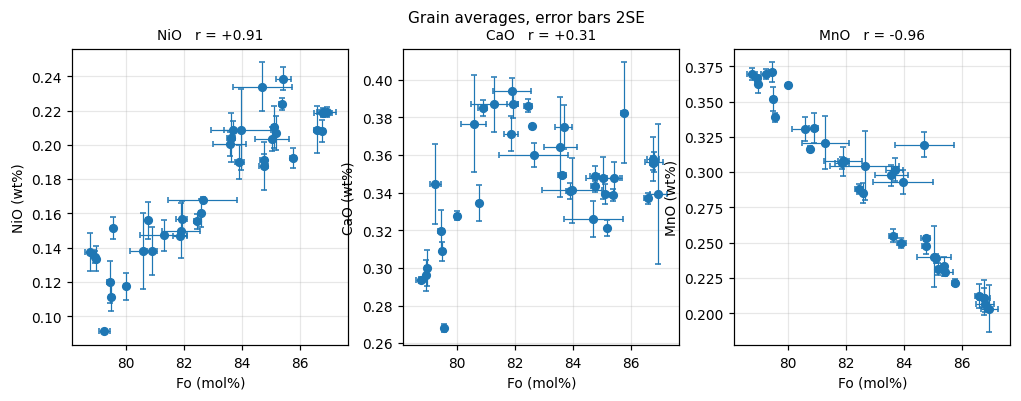

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True)
for ax, ox in zip(axs, ["NiO", "CaO", "MnO"]):
    g = avg.query("oxide == @ox").set_index("sample")
    f = avg.query("oxide == 'Fo'").set_index("sample")
    ax.errorbar(f["mean"], g["mean"], xerr=f["2SE"], yerr=g["2SE"], fmt="o", ms=5, lw=.8, capsize=2)
    ax.set(xlabel="Fo (mol%)", ylabel=f"{ox} (wt%)")
    ax.grid(alpha=.3)
    r = np.corrcoef(f["mean"], g["mean"])[0, 1]
    ax.set_title(f"{ox}   r = {r:+.2f}", fontsize=9)
fig.suptitle("Grain averages, error bars 2SE", fontsize=10)
if SAVE: fig.savefig(FIG / "fig05_fo_vs_minors.png")
plt.show()

Fo spans 78.7–87.2 across 37 grains. NiO correlates strongly and positively with Fo and MnO negatively — the fractional-crystallisation signature, since Ni is compatible in olivine and Mn is not. CaO is flat, as expected for a minor element buffered by the melt rather than by olivine fractionation. That is the geochemistry for the results section; the point here is only that these trends survive the processing, and that the NiO–Fo trend would be invisible if the session had run at the glass session's 10 nA, where NiO would have sat near its detection limit.

## 13. Save

In [17]:
if SAVE:
    smp.to_csv(OUT / "olivine_spots_flagged.csv", index=False)
    avg.to_csv(OUT / "olivine_grain_averages.csv", index=False)
    prec.to_csv(OUT / "olivine_precision.csv")
    acc.to_csv(OUT / "olivine_accuracy.csv")
    qt.to_csv(OUT / "olivine_qtest_flags.csv", index=False)
    z.to_csv(OUT / "olivine_zoning.csv")
print(OUT, "\n ", "\n  ".join(sorted(p.name for p in OUT.glob("*.csv"))))
print(FIG, "\n ", "\n  ".join(sorted(p.name for p in FIG.glob("*.png"))))

c:\Users\vallejad\Documents\VSCode\igneous_project02\outputs\olivine 
  olivine_accuracy.csv
  olivine_grain_averages.csv
  olivine_precision.csv
  olivine_qtest_flags.csv
  olivine_spots_flagged.csv
  olivine_zoning.csv
c:\Users\vallejad\Documents\VSCode\igneous_project02\figures\olivine 
  fig01_drift_olivine.png
  fig02_accuracy_vs_precision_olivine.png
  fig03_totals_olivine.png
  fig04_contamination_screen.png
  fig05_fo_vs_minors.png


## Carry into the report

| | |
|---|---|
| Precision (SC-Ol, n = 15) | MgO 0.6 %, FeO 1.5 %, CaO 4 %, MnO 6 %, NiO 13 %, Al₂O₃ 23 %, Cr₂O₃ 85 % 2RSD |
| Drift | SiO₂ +4 % over 7 h, 7× the within-bracket 2SD → **corrected**, time-interpolated between five brackets |
| Correction validated | SC-Ol SiO₂ 2RSD 3.1 % → 0.4 %; cation ratio 2.051 → 2.013 against a 2.014 target |
| Accuracy | **CaO +10.6 %** (Wollastonite-calibrated, extrapolated 500×); NiO −4.5 %, MnO +2.4 % within 2SD; MgO +0.6 % — so the glass session's +6 % MgO is glass-specific |
| Totals | uniform +1.5 % offset that the standard does not share, stoichiometry normal → scale error, reported not normalised; **no spot rejected on total** |
| Spots removed | 0 of 113 — no contamination, no crystal hits, Q-test powerless at n = 3 |
| Fo | recomputed, agrees with `_ratios` to <0.01 mol%; uncertainty ±0.1 mol%; range 78.7–87.2 |
| Zoning | 10 of 37 grains span >0.5 mol% Fo, up to 1.85 — averaged but flagged, 2SD quoted |
| Not quantitative | Cr₂O₃ |

Methodological contrast worth a paragraph: the glass session had drift too small to correct and outliers the Q-test could catch (n = 9 per sample); the olivine session had drift large enough to demand correction and n = 3, where the Q-test is useless. Same instrument, opposite treatment — and in both cases the decision followed from comparing the effect against the measured precision rather than from a rule applied blind.